<div style="text-align: center;">
<h1>Wheel Strategy vs Buy-and-Hold: A Backtesting Study on SPY</h1>
<h1>Yingxin Deng</h1>
<h1>5/5/2026</h1>
</div>

## Abstract
The Wheel Strategy is a popular options-based trading strategy that aims to generate consistent income through selling cash-secured puts and covered calls. In this project, I implement and backtest a dynamic Wheel Strategy on SPY, incorporating regime-based parameter adjustments and volatility estimation. I compare its performance against a buy-and-hold benchmark over different starting periods. My findings suggest that while the Wheel Strategy provides downside protection during short-term bearish markets, it significantly underperforms buy-and-hold in long-term bullish trends due to its limited upside exposure. Therefore, the Wheel Strategy may be better suited as a short-term or defensive strategy rather than a long-term investment approach.

## Introduction

The Wheel Strategy is a widely used options trading strategy that combines selling cash-secured puts and covered calls. The basic idea is to generate income from option premiums while gradually acquiring and disposing of shares of an underlying asset.

When the investor does not hold the underlying asset, they sell cash-secured puts to collect premium and potentially acquire the stock at a lower price. Once assigned, the investor sells covered calls against the shares, generating additional income until the shares are called away. This cycle continues indefinitely.

While the Wheel Strategy is often promoted as a stable income-generating approach, its performance relative to a passive buy-and-hold strategy remains an open question. In this project, I investigate whether the Wheel Strategy can outperform simply holding SPY over time.

## Set Up

In [69]:
!pip install yfinance pandas numpy matplotlib scipy

In [70]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Data
I use historical daily price data of SPY (S&P 500 ETF) from 2015 to 2025. The adjusted closing price is used to construct both strategies.

To estimate option pricing inputs, I compute a rolling 21-day volatility:


In [71]:
spy = yf.download("SPY", start="2015-01-01", end="2025-01-01")

spy = spy["Close"]

if isinstance(spy, pd.DataFrame):
    spy = spy.iloc[:, 0]

spy = pd.DataFrame({"price": spy})
spy = spy.dropna()

spy.head()

[*********************100%***********************]  1 of 1 completed


,price
Date,
2015-01-02,170.125031
2015-01-05,167.052612
2015-01-06,165.479126
2015-01-07,167.541260
2015-01-08,170.514236


This serves as the volatility input in the Black-Scholes pricing model used to simulate option premiums.

In [3]:
returns = spy["price"].pct_change()

rolling_vol = returns.rolling(21).std() * np.sqrt(252)

rolling_vol = rolling_vol.fillna(0.20)
rolling_vol = rolling_vol.clip(lower=0.10, upper=0.60)

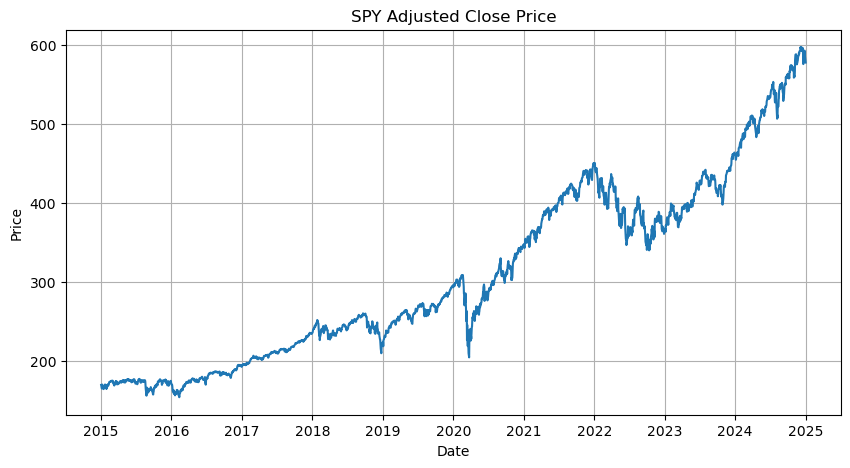

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(spy.index, spy["price"])
plt.title("SPY Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

## Method

## 1. Important Note on Strategy Definition**

The Wheel Strategy implemented in this project is not exactly the same as the traditional Wheel Strategy. A traditional Wheel Strategy usually follows a fixed cycle: sell cash-secured puts, wait to be assigned, sell covered calls after receiving shares, and repeat the process after the shares are called away.

However, in this project, I modify the strategy based on my own understanding and research objective. Instead of strictly following the traditional Wheel cycle, I introduce several adjustments, such as regime-based parameter changes and active stock purchases when puts are not assigned. These modifications are intended to reduce the problem of staying in cash for too long during bull markets and to make the strategy more adaptive to different market conditions.

Therefore, the strategy tested in this project should be interpreted as a modified Wheel Strategy, rather than a pure traditional Wheel Strategy.

## 2. Wheel Strategy Implementation


I implement a realistic version of the Wheel Strategy with the following features:

Selling cash-secured puts when no shares are held
Selling covered calls when shares are held
Option pricing using the Black-Scholes model
Contract size fixed at 100 shares

To improve realism, I introduce dynamic parameter adjustment based on market conditions.

In [80]:
def backtest_wheel(
    prices,
    rolling_vol,
    initial_cash=100000,
    contract_size=100,
    r=0.04,
    force_buy_after_days=14,
    force_buy_fraction=0.50
):
    prices = prices.astype(float)
    rolling_vol = rolling_vol.reindex(prices.index).fillna(0.20).clip(0.10, 0.60)

    # Use the 20-day moving average to determine the market condition
    ma20 = prices.rolling(20).mean()

    cash = float(initial_cash)
    shares = 0
    days_without_assignment = 0

    portfolio_values = []
    dates = []

    i = 0

    while i < len(prices) - 1:
        S0 = float(prices.iloc[i])
        sigma = float(rolling_vol.iloc[i])

        # The 20-day moving average (MA20) for the previous 20 days may be NaN. By default, it is regarded as not an increase.
        if not np.isnan(ma20.iloc[i]) and S0 > float(ma20.iloc[i]):
            # Rising Market: Look at the long-term picture with strike option, avoid exercising it too quickly
            put_otm = 0.10
            call_otm = 0.10
            days_to_expiry = 7
        else:
            # Horizontal/Downward Market: Strike at a lower price, Buy at a higher premium
            put_otm = 0.04
            call_otm = 0.04
            days_to_expiry = 7

        if i + days_to_expiry >= len(prices):
            break

        S_expiry = float(prices.iloc[i + days_to_expiry])
        T = days_to_expiry / 252

        # Case 1: no shares, sell cash-secured puts
        if shares == 0:
            K = S0 * (1 - put_otm)
            required_cash = K * contract_size
            num_contracts = int(cash // required_cash)
        
            if num_contracts > 0:
                premium_per_contract = (
                    black_scholes_price(S0, K, T, r, sigma, "put") * contract_size
                )
                cash += premium_per_contract * num_contracts

            # If assigned, buy shares at strike K
            if S_expiry < K:
                cash -= required_cash * num_contracts
                shares += contract_size * num_contracts
    
            # If not assigned, directly buy the same number of shares at market price
            else:
                shares_to_buy = contract_size * num_contracts
                cost = shares_to_buy * S_expiry
    
                if cash >= cost:
                    cash -= cost
                    shares += shares_to_buy

        # Case 2: holding shares, sell covered calls
        else:
            K = S0 * (1 + call_otm)
            num_contracts = int(shares // contract_size)

            if num_contracts > 0:
                premium_per_contract = (
                    black_scholes_price(S0, K, T, r, sigma, "call") * contract_size
                )
                cash += premium_per_contract * num_contracts

                if S_expiry > K:
                    cash += K * contract_size * num_contracts
                    shares -= contract_size * num_contracts

            days_without_assignment = 0

        portfolio_value = cash + shares * S_expiry
        portfolio_values.append(float(portfolio_value))
        dates.append(prices.index[i + days_to_expiry])

        i += days_to_expiry

    result = pd.DataFrame(index=dates)
    result["portfolio_value"] = portfolio_values

    return result

## 3. Buy-and-Hold Benchmark

As a benchmark, I implement a buy-and-hold strategy:

Invest $100,000 in SPY at the start date
Hold shares without trading

In [81]:
initial_cash = 100000

buy_hold = pd.DataFrame(index=spy.index)
buy_hold["price"] = spy["price"]

shares_bh = initial_cash / buy_hold["price"].iloc[0]
buy_hold["portfolio_value"] = shares_bh * buy_hold["price"]

buy_hold.head()

,price,portfolio_value
Date,,
2015-01-02,170.125031,100000.000000
2015-01-05,167.052612,98194.023417
2015-01-06,165.479126,97269.123464
2015-01-07,167.541260,98481.251851
2015-01-08,170.514236,100228.776407


## 4. Black-Scholes Option Pricing Model

In this project, option premiums are estimated using the Black-Scholes pricing model. This model provides a theoretical price for European call and put options based on several key inputs.

$$
d_1 = \frac{\ln\left(\frac{S}{K}\right) + \left(r + \frac{1}{2}\sigma^2\right)T}{\sigma \sqrt{T}}
$$

$$
d_2 = d_1 - \sigma \sqrt{T}
$$

The Black-Scholes model assumes that the underlying asset follows a lognormal price process with constant volatility and no arbitrage opportunities. The main inputs to the model are:

- $S$: Current price of the underlying asset  
- $K$: Strike price of the option  
- $T$: Time to maturity (in years)  
- $r$: Risk-free interest rate  
- $\sigma$: Volatility of the underlying asset  

Using these inputs, the model calculates the fair value of both call and put options. In this project, we use the model to estimate the premium received when selling options as part of the Wheel Strategy.

Although the Black-Scholes model relies on simplifying assumptions (such as constant volatility and no transaction costs), it provides a reasonable approximation for option pricing in a backtesting framework. Therefore, it allows us to simulate option premiums in a consistent and tractable way.

In [76]:
def black_scholes_price(S, K, T, r, sigma, option_type="call"):
    """
    S: current stock price
    K: strike price
    T: time to expiration in years
    r: risk-free rate
    sigma: implied volatility
    option_type: "call" or "put"
    """
    if T <= 0:
        if option_type == "call":
            return max(S - K, 0)
        else:
            return max(K - S, 0)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

## 5. Multi-Start Backtesting

To reduce dependence on entry timing, I perform backtests across multiple starting dates (2015–2022). This allows us to evaluate performance across different market conditions.

In [82]:
start_dates = [
    "2015-01-01",
    "2016-01-01",
    "2017-01-01",
    "2018-01-01",
    "2019-01-01",
    "2020-01-01",
    "2021-01-01",
    "2022-01-01",
]

results = {}

for start in start_dates:
    sub_data = spy.loc[start:].copy()
    
    # clean price series
    sub_prices = sub_data["price"]
    if isinstance(sub_prices, pd.DataFrame):
        sub_prices = sub_prices.iloc[:, 0]
    sub_prices = sub_prices.astype(float)
    
    # rolling volatility for this start date
    sub_returns = sub_prices.pct_change()
    sub_rolling_vol = sub_returns.rolling(21).std() * np.sqrt(252)
    sub_rolling_vol = sub_rolling_vol.fillna(0.20).clip(0.10, 0.60)
    
    # Wheel Strategy
    wheel = backtest_wheel(
        sub_prices,
        sub_rolling_vol
    )
    
    # Buy and Hold benchmark
    initial_cash = 100000
    shares_bh = initial_cash / sub_prices.iloc[0]
    buy_hold_series = shares_bh * sub_prices
    
    # Align dates
    comp = pd.DataFrame(index=wheel.index)
    comp["Wheel"] = wheel["portfolio_value"]
    comp["Buy and Hold"] = buy_hold_series.reindex(wheel.index)
    comp = comp.dropna()
    
    results[start] = comp

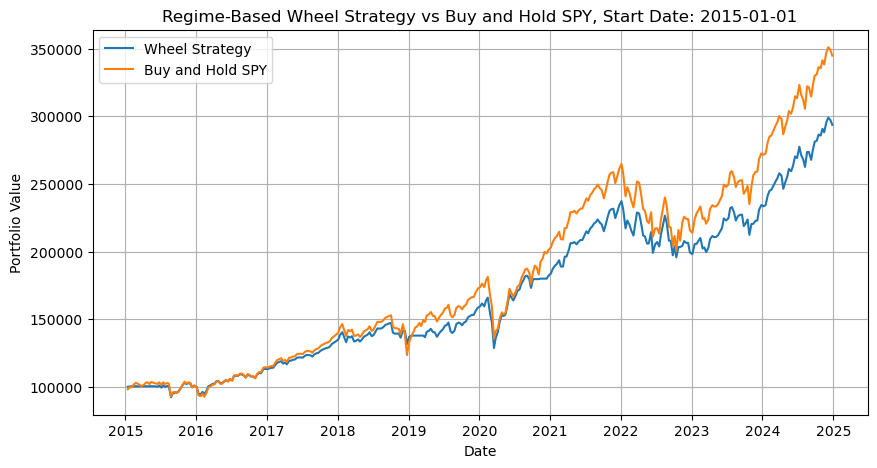

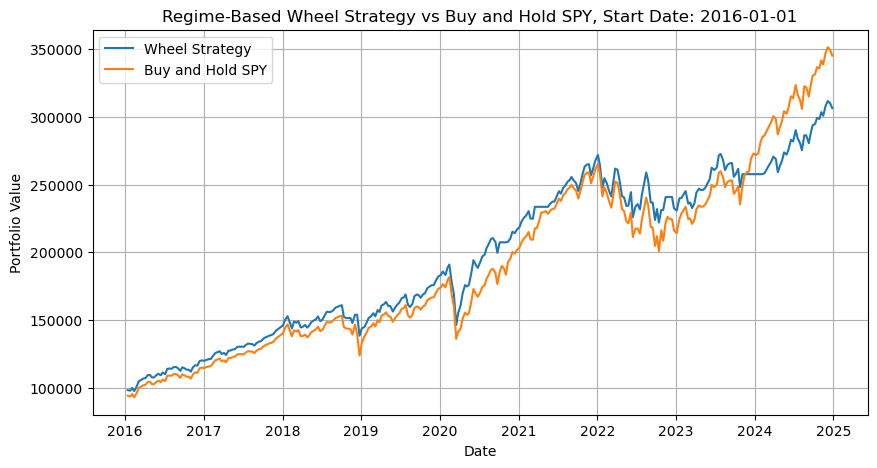

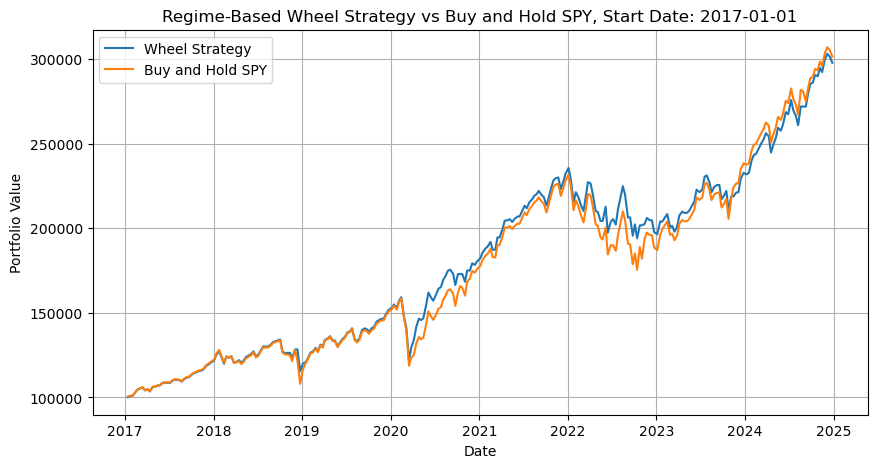

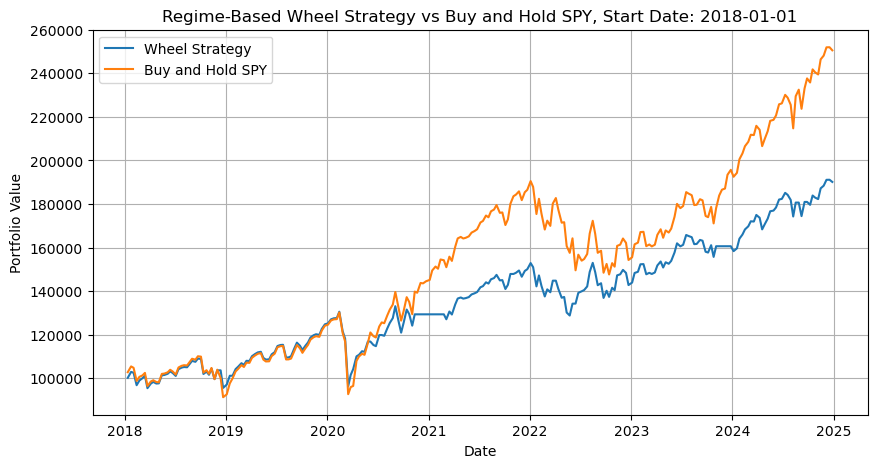

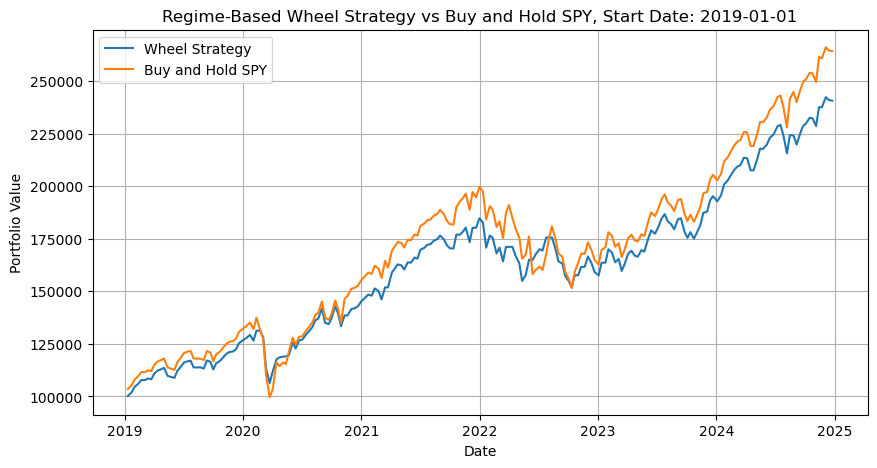

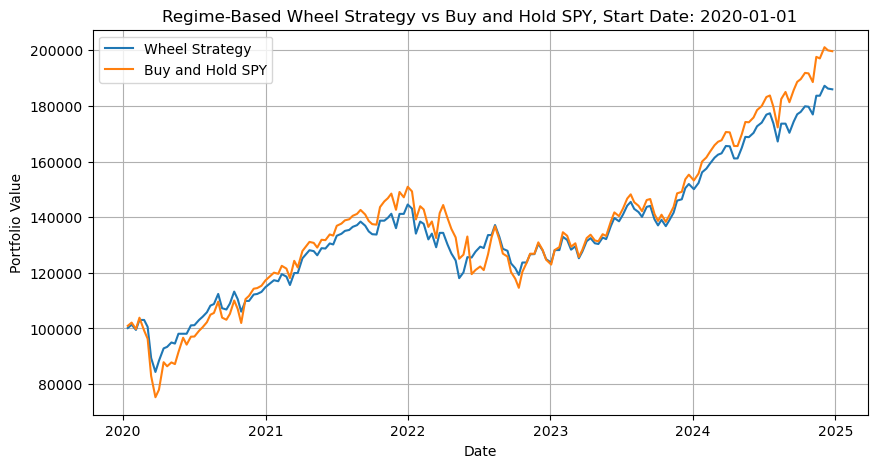

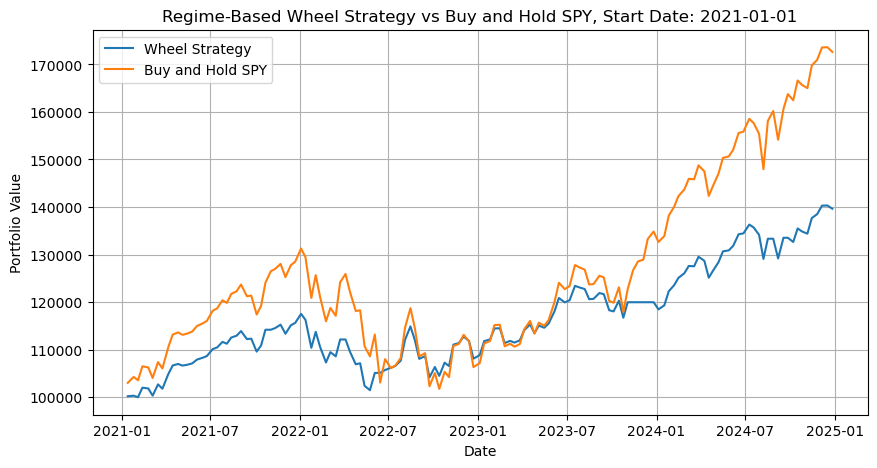

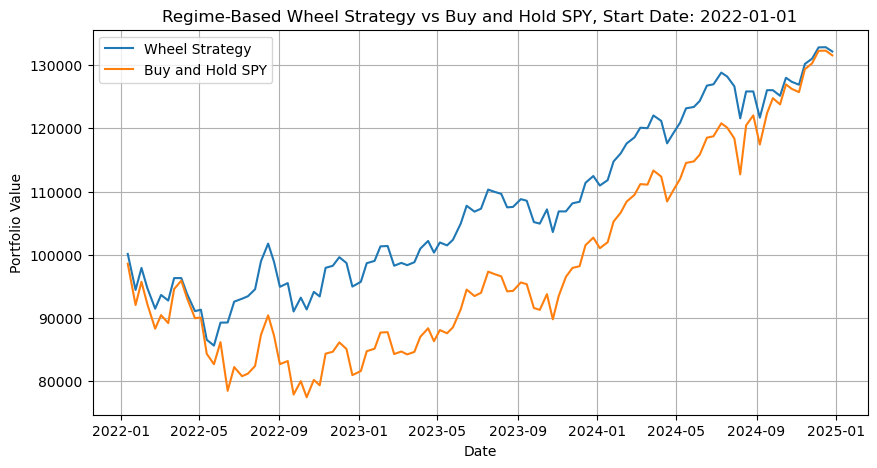

In [78]:
for start, comp in results.items():
    plt.figure(figsize=(10, 5))
    
    plt.plot(comp.index, comp["Wheel"], label="Wheel Strategy")
    plt.plot(comp.index, comp["Buy and Hold"], label="Buy and Hold SPY")
    
    plt.title(f"Regime-Based Wheel Strategy vs Buy and Hold SPY, Start Date: {start}")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid(True)
    plt.show()

## Results
## 1. Long-Term Performance

Across most starting dates, the buy-and-hold strategy significantly outperforms the Wheel Strategy over long horizons.

This is especially evident during strong bull markets (e.g., post-2020), where SPY experiences sustained upward trends.

The Wheel Strategy tends to underperform because:

1. Covered calls cap upside gains
2. Positions are frequently closed during rallies
3. The strategy fails to maintain continuous market exposure

## 2. Behavior in Bull Markets

During strong upward trends, the Wheel Strategy repeatedly sells covered calls, which results in shares being called away. As a result, the strategy often exits positions prematurely and misses large price increases.

Even with regime-based adjustments, the strategy cannot fully capture long-term growth due to its inherent structure.

## 3. Behavior in Bear and Sideways Markets

In contrast, the Wheel Strategy performs relatively well during:

1. Short-term market downturns
2. Sideways or range-bound periods

This is because:

1. Option premiums provide steady income
2. Losses are partially offset by premium collection
3. Lower volatility environments favor premium-selling strategies

Thus, the Wheel Strategy provides downside protection compared to buy-and-hold.

## Conclusion

In this project, I evaluate the performance of the Wheel Strategy relative to a buy-and-hold approach using SPY.

My results show that:

1. The Wheel Strategy does not outperform buy-and-hold in the long run
2. It consistently underperforms in strong bull markets due to limited upside
3. However, it offers partial protection during short-term bearish or sideways markets

Overall, the Wheel Strategy is not suitable as a long-term investment strategy, but may be useful as a short-term income or defensive strategy depending on market conditions.

## Final Reflection

Before I was formally introduced to the Wheel Strategy, my understanding of options was limited to the basic concepts of calls and puts. At that time, I had neither the motivation nor the discipline to actively trade short-term options, especially strategies that require closely monitoring the market early in the morning. As a result, I began thinking about a more systematic and less time-intensive approach to trading SPY options. The initial idea that I implemented in this project originated from that intuition.

As I continued to research and refine this idea, I realized that my approach closely resembled the Wheel Strategy, which is already a well-known and widely discussed strategy in quantitative trading. This was both encouraging and insightful, as it showed that my intuition aligned with existing financial strategies.

However, when I shared my idea with others, I often received feedback suggesting that the strategy might not provide a clear advantage over simpler alternatives. Through the process of implementing and rigorously backtesting the strategy in this project, I have come to better understand these concerns. The results confirm that, while the Wheel Strategy can offer some level of downside protection in certain market conditions, it does not outperform a buy-and-hold approach in the long run.

This experience has been valuable not only in understanding the limitations of the Wheel Strategy, but also in learning how to critically evaluate trading ideas through data and modeling. It highlights the importance of moving beyond intuition and validating strategies through quantitative analysis.